In [11]:
import numpy as np
from numpy.typing import ArrayLike
from scipy.optimize import least_squares
from scipy.optimize import OptimizeResult

## **TEORÍA**
---

Estimacion del coeficiente de reflexion de la fuente (Gamma_s, "source match") de un generador de senales, con el setup de acoplador direccional + linea de transmision (carga deslizante / offset loads), siguiendo el metodo de Furrer/de Vreede con trazabilidad metrologica (Juroshek, NPL):

https://www.researchgate.net/publication/333078487_Measuring_Signal_Generator_Source_Match

### SetUp de Medición

El generador alimenta un acoplador direccional; en el brazo acoplado se mide
potencia escalar (medidor de potencia / analizador de espectro). En la salida
del acoplador direccional, se conecta una carga con $\Gamma_L$ (magnitud y fase) 
variable. Para realizar mediciones similares al paper, la carga será una linea de 
transmisión con longitud variable conectada al otro extremo en *Short* o en *Open*.

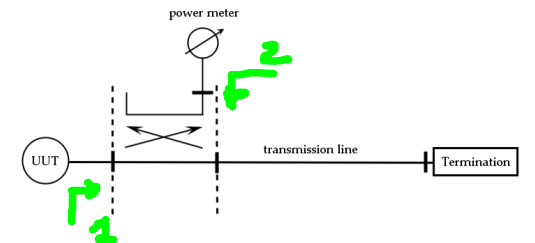

### Instrucciones de Medición

* Se caracteriza el conjunto acoplador direccional y carga (linea de transmisión) con un VNA.
* Se conecta el DUT al setup de medición.
* Se realiza la medición de potencia.
* Se repite el proceso con todas las cargas.  

### Modelo Matemático

La potencia medida por el conjunto, luego de realizar grafos y resolver, presenta la siguiente ecuación:

$$P = P_g\,\frac{|S_{21}|^2\,(1-|\Gamma_s|^2)}{\left|(1-\Gamma_g S_{11})(1-\Gamma_s S_{22}) - \Gamma_g\Gamma_s S_{12}S_{21}\right|^2}$$

Se obtiene el valor de $\Gamma_g$ con métodos regresivos, minimizando la ecuación obtenida 
con distintos valores de $\Gamma_g$.

### Método de cuadrados míminos

Se define una variable a estimar $\theta$, con un modelo $f(\theta)$ que entrega resultados (las mediciones) $y$.
Este método intenta minimizar los residuos, definidos como:
$$res=y-f(\theta)$$

En caso de realizar múltimes mediciones, se busca minimizar la suma cuadrática de residuos:
$$h=\sum_{i=0}^{N} {res_i}^2$$

Para minimizar, derivamos e igualamos a 0:

$$\frac{dh}{\theta}=2 \sum_{i=0}^{N} res_i \cdot \frac{d res_i}{\theta}$$

Definimos Jacobiano a la matriz de derivadas, $J=\frac{d res_i}{\theta}$​, de forma que:

$$\begin{aligned}
\frac{dh}{\theta} & =2 \sum_{i=0}^{N} res_i \cdot J \\
\frac{dh}{\theta} & =2 J^T \cdot res \\
\frac{dh}{\theta} & = 0 = J^T \cdot res \\
F & = J^T \cdot res \\
F & =0 
\end{aligned}$$

Todo esto es amplaimente conocido como método y se resuelve mediante least_squares de scipy.

### Incertidumbre

La incertidumbre en el paper fue calculada utilizando software específico
para la propagación de error, basado en metodologías GUM indicadas en papers previos.

#### **Incertidumbre de los resuduos:**

El GUM (seccion 5.1.4 / Supplement 2) indica que cuando el "modelo" es un algoritmo/procedimiento, los coeficientes de sensibilidad $S_k = d(\theta)/d(X_k)$ se obtienen evaluando como cambia el resultado ante variaciones de cada entrada.

Sea $\theta$ el conjunto de todos los valores estimados (sea $\gamma_g$ y $P_g$) y $X$ todos los parámetros de entrada; se define la sensibilidad como:

$$\frac{d\theta}{dX_k}= -\frac{\frac{dF}{dX_k}}{\frac{dF}{d\theta}}$$

Comenzamos por la primer derivada $\frac{dF}{dX_k}$. Esta está indicada en el paper como:
$$\frac{dF}{dX_k}= -\sqrt{\frac{h_{min}}{N-p}} $$

Siendo:
* $h_{min}$: Suma cuadrática de residuos, obtenida como `res.cost`.
* N: Cantidad de mediciones distintas.
* p: Cantidad de variables predichas (3 en nuestro caso).

Ahora vamos con la segunda derivada $\frac{dF}{d\theta}$:
Se obtiene derivando la teoría del método de estimación

$$\begin{aligned}
F & = J^T \cdot res \\
F & = J\cdot \sum_{i=0}^{N} res_i \\
\frac{dF}{dX} & =\sum_{i} \frac{dJ_i}{dX} res_i + \sum_{i} J\frac{dres_i}{dX} \\
\frac{dF}{dX} & =\sum_{i} \frac{d^2res_i}{dX^2} res_i + \sum_{i} {J_i}^2
\end{aligned}$$


Acá aparece la aproximación de Gauss Jordan, donde la segunda derivada se desprecia (ya que se aplica a un residuo, cuyo valor debería ser 0 o cercano) 
y nos quedamos solo con la $J^2$:
$$\begin{aligned}
\frac{dF}{dX} & \approx \sum_{i} {J_i}^2 \\
\frac{dF}{dX} & = J^T \cdot J
\end{aligned}$$

Combinando todo, la incertidumbre de nuestra medición es:

$$u(\theta) = \sqrt{\frac{h_{min}}{N-3}} \cdot (J^T J)^{-1}$$

#### **Incertidumbre de los valores:**

Los valores "conocidos" poseen una incertidumbre asociada. Su cálculo es sencilo e igual que de costumbre:
$$ u(\theta) = \left|\frac{d\theta}{dX} \right| \cdot u(X) $$

El problema es que $\theta$ se obtuvo por métodos numéricos y no se posee su fórmula. 
Se resuelve la derivada con un método de "fuerza bruta", realizando la estimación de $\theta$ nuevamente con un $\Delta X$ sumado:
$$\frac{d\theta}{dX} = S = \frac{\theta(X+\Delta X) - \theta(X)}{\Delta X}$$

Quedando el resultado:

$$u(\theta) = S \cdot u(X) \cdot S^T$$


#### **Incertidumbre de los valores:**
La incertidumbre total se obtiene como:
$$\begin{aligned}
u(\theta)_{tot} & = u_{valores}(\theta) + u_{residuos}(\theta) \\
u(\theta)_{tot} & = S \cdot u(X) \cdot S^T + \sqrt{\frac{h_{min}}{N-3}} \cdot (J^T J)^{-1} 
\end{aligned}$$


## **RESOLUCIÓN**
---

### Funciones Auxiliares

In [12]:
# Combina todos los datos en un "paquete"
# X = [Re/Im S11 (N), Re/Im S21 (N), Re/Im S12 (N), Re/Im S22 (N), Re/Im Gs, P (N)]
def pack(S11 : complex, S21 : complex, S12 : complex, S22 : complex, Gs : complex, P : int):
    '''pack

    Empaqueta todos los datos en una única variable
    
    Params
    ---
    S11 : '''
    parts = []
    for S in (S11, S21, S12, S22):
        parts += [np.real(S), np.imag(S)]
    parts += [np.array([Gs.real, Gs.imag]), np.asarray(P, float)]
    return np.concatenate(parts)

def unpack(X : list, N : int):
    '''unpack

    Separa los datos empaquetados.

    Params
    ---
    X : list    
        Paquete de datos a desempaquetar.
    N : int
        Cantidad de paquetes.
    '''
    S = []
    for k in range(4):
        S.append(X[2 * k * N:(2 * k + 1) * N] + 1j * X[(2 * k + 1) * N:(2 * k + 2) * N])
    Gs = X[8 * N] + 1j * X[8 * N + 1]
    P = X[8 * N + 2:8 * N + 2 + N]
    return S[0], S[1], S[2], S[3], Gs, P
  
def groups(N):
    '''Indices de X por grupo (para el presupuesto de incertidumbre).'''
    return {
        "S-parametros (VNA)": np.arange(0, 8 * N),
        "Gamma_s del sensor": np.arange(8 * N, 8 * N + 2),
        "Potencias P_i": np.arange(8 * N + 2, 9 * N + 2),
    }

def tabla(headers, rows):
    '''Tabla ASCII simple: primera columna a la izquierda, el resto a la derecha.'''
    w = [max(len(str(h)), *(len(str(r[i])) for r in rows)) for i, h in enumerate(headers)]
    sep = "+" + "+".join("-" * (a + 2) for a in w) + "+"
 
    def fila(r):
        celdas = [str(c).ljust(a) if i == 0 else str(c).rjust(a)
                  for i, (c, a) in enumerate(zip(r, w))]
        return "| " + " | ".join(celdas) + " |"
 
    return "\n".join([sep, fila(headers), sep] + [fila(r) for r in rows] + [sep])
 
 
def titulo(txt):
    print("\n" + txt)
    print("=" * len(txt))

### Estimación de Valor

In [13]:
def model_power(Gg : complex, Pg : float, Gs : complex, S11 : complex, S21 : complex, S12 : complex, S22 : complex) -> float:
    '''model_power

    Ecuación que modela P en función de los parámetros de entrada.
    '''
    den = (1 - Gg * S11) * (1 - Gs * S22) - Gg * Gs * S12 * S21
    return Pg * np.abs(S21) ** 2 * (1 - np.abs(Gs) ** 2) / np.abs(den) ** 2
 

def _fit(X : list, N : int, init_value, Pscale) -> OptimizeResult:
    '''_fit
    
    Realiza el fit del modelo con los datos X y el valor inicial init_value
    Params
    ---
    X : array, largo nX
        Magnitudes de influencia medidas, empaquetadas con pack():
        partes Re/Im de S11,S21,S12,S22 (8N valores), Re/Im de
        Gamma_s (2 valores) y las N potencias P_i.
    N : int
        Numero de redes medidas (una potencia P_i por red).
    init_value:
        Vector con valores iniciales. Tiene la forma [X, Y, PG] siendo gamma_g = X + jY
    Pscale:
    '''
    S11, S21, S12, S22, Gs, P = unpack(X, N)
    Pn = P / Pscale
 
    def resid(th):
        return model_power(th[0] + 1j * th[1], th[2], Gs, S11, S21, S12, S22) - Pn
 
    return least_squares(resid, init_value,
                         bounds=([-0.999, -0.999, 1e-12], [0.999, 0.999, np.inf]),
                         method="trf", x_scale="jac",
                         xtol=1e-15, ftol=1e-15, gtol=1e-15)
 
def fit_gamma_g(X : list, N : int, n_starts : int = 30, seed : int = 0):
    '''Ajuste global con multi-arranque. Devuelve theta=(x,y,pg_normalizado), Pscale, res.'''
    P = unpack(X, N)[5]
    Pscale = np.mean(P)
    S11, S21, S12, S22, Gs, _ = unpack(X, N)
    pg0 = np.mean(P / (np.abs(S21) ** 2 * (1 - abs(Gs) ** 2))) / Pscale
    rng = np.random.default_rng(seed)

    best = None
    for k in range(n_starts):
        initial_gamma = [0.0, 0.0] if k == 0 else list(rng.uniform(-0.4, 0.4, 2))
        res = _fit(X, N, initial_gamma + [pg0], Pscale)
        if best is None or res.cost < best.cost:
            best = res
    return best.x, Pscale, best


### Inceritdumbre

In [14]:
def uncertainty(
        X : list, 
        N : int , 
        cov_X : ArrayLike, 
        theta : ArrayLike, 
        Pscale : float, 
        res : OptimizeResult, 
        step : float =1e-6):
    '''
    Propaga la incertidumbre de las magnitudes de entrada hacia la covarianza de (Re(Gamma_g), Im(Gamma_g), Pg [W]), siguiendo el metodo de Hall (ecs. 5-7 del paper).

    Combina dos componentes:
      (a) Sensibilidad a las magnitudes de influencia (ec. 6): para cada componente de X se calcula d(theta)/d(X_k) perturbando
      X_k +-h y reajustando el modelo (funcion implicita evaluada por diferencias centrales), y se propaga cov_X a traves de esas sensibilidades.
      (b) Calidad del ajuste (ec. 7): s^2 (J^T J)^-1 con s^2 = h_min / (N - p), que capta el error no explicado por 
      el modelo (ruido de medicion, redes mal caracterizadas, modelo inadecuado a la frecuencia de trabajo, etc.).

    Ambas componentes se suman en cuadratura para dar la covarianza
    total, y ademas se desglosa (a) por grupo de magnitudes (S-params,
    Gamma_s, potencias) para armar un presupuesto de incertidumbre.

    Parametros
    ----------
    X : array, largo nX
        Magnitudes de influencia medidas, empaquetadas con pack():
        partes Re/Im de S11,S21,S12,S22 (8N valores), Re/Im de Gamma_s (2 valores) y las N potencias P_i.
    N : int
        Numero de redes medidas (una potencia P_i por red).
    cov_X : matriz nX x nX
        Covarianza de X. Diagonal si las magnitudes son independientes; con terminos fuera de la diagonal si hay correlaciones 
        (p.ej. errores comunes de calibracion del VNA entre distintos S-params).
    theta : array (x, y, pg_norm)
        Solucion del ajuste en el punto optimo: Re(Gamma_g), Im(Gamma_g) y Pg normalizado por Pscale.
    Pscale : float
        Factor de escala usado para normalizar Pg durante el ajuste.
    res : OptimizeResult
        Resultado de least_squares en el optimo (contiene res.jac y res.cost = h_min/2).
    step : float, opcional
        Paso relativo para la diferencia central: h_k = step * max(1, |X_k|).

    Devuelve
    --------
    cov : matriz 3x3
        Covarianza total de (Re(Gamma_g), Im(Gamma_g), Pg[W]).
    budget : dict[str, matriz 3x3]
        Covarianza aportada por cada grupo de entradas y por la
        calidad del ajuste ("Calidad del ajuste (residuos)").
    s : float
        sqrt(h_min/(N-p)), indicador de bondad de ajuste.
    '''
    cant_estimaciones = 3
    cant_variables = len(X)

    # Matriz de escalado (solo debe afectar a Pg): 
    # X  [1 0 0 ]
    # Y  [0 1 0 ]
    # Pg [0 0 Pg]
    scale = np.diag([1.0, 1.0, Pscale])

    # Incertidumbre de residuos, Ecuacion del Paper
    Jacobian = res.jac
    dF_dX = 2 * res.cost / max(N - cant_estimaciones, 1)
    dF_dr = Jacobian.T @ Jacobian
    cov_res = scale @ (dF_dX * np.linalg.pinv(dF_dr)) @ scale.T

    # Incertidumbre de mediciones
    Sens = np.zeros((cant_estimaciones, cant_variables))
    for k in range(cant_variables):
        x2, x1 = X.copy(), X.copy()         # X+ΔX, X-ΔX
        delta_x = step * max(1.0, abs(X[k]))
        x2[k] += delta_x
        x1[k] -= delta_x
        y2 = _fit(x2, N, theta, Pscale).x
        y1 = _fit(x1, N, theta, Pscale).x
        Sens[:, k] = (y2 - y1) / (2*delta_x)          # derivada = (f(X + ΔX)-f(X - ΔX)) / 2ΔX 
 
    Sens_W = scale @ Sens
    cov_inputs = Sens_W @ cov_X @ Sens_W.T

 
    budget = {}
    for name, idx in groups(N).items():
        Sg = Sens_W[:, idx]
        budget[name] = Sg @ cov_X[np.ix_(idx, idx)] @ Sg.T
    budget["Calidad del ajuste (residuos)"] = cov_res
 
    return cov_inputs + cov_res, budget, np.sqrt(dF_dX)

## Ejemplo

In [15]:
def build_networks(f=1e9, eps_r=2.05, loss_db_per_m=0.3):
    '''8 redes: largos 0/70/100/150 cm x (open, short). Valores INVENTADOS.'''
    c0 = 299792458.0
    beta = 2 * np.pi * f / (c0 / np.sqrt(eps_r))
    alpha = loss_db_per_m / 8.686
    Gm = 0.04 * np.exp(1j * 0.6)      # desadaptacion del acoplador (puerto 1)
    G2 = 0.02 * np.exp(1j * 2.0)      # desadaptacion del brazo monitor
    t, c = 0.98, 0.10                 # transmision directa, acoplamiento (-20 dB)
    d = 0.03 * np.exp(-1j * 1.0)      # fuga por directividad finita
    S11, S21, S22 = [], [], []
    for l in (0.0, 0.70, 1.00, 1.50):
        for T in (+0.98, -0.98):      # open / short
            GL = T * np.exp(-2 * (alpha + 1j * beta) * l)
            S11.append(Gm + t ** 2 * GL)
            S21.append(c * (d + GL))
            S22.append(G2)
    S11, S21, S22 = map(np.array, (S11, S21, S22))
    return S11, S21, S21.copy(), S22   # reciprocidad: S12 = S21
 
 
if __name__ == "__main__":
    rng = np.random.default_rng(1)
 
    # Valores Verdaderos
    Gg_true, Pg_true = 0.05 + 0.03j, 2e-3
    Gs_true = 0.02 - 0.01j
    S11t, S21t, S12t, S22t = build_networks()
    N = len(S11t)
    P_true = model_power(Gg_true, Pg_true, Gs_true, S11t, S21t, S12t, S22t)
 
    # Incertidumbres de Instrumental
    u_S = 0.003          # por componente re/im de cada S-parametro (VNA)
    u_Gs = 0.005         # por componente de Gamma_s
    u_Prel = 0.002       # relativa de cada lectura de potencia (0.2 %)
 
    # Valores medidos (Real + ruido)
    X_true = pack(S11t, S21t, S12t, S22t, Gs_true, P_true)
    u = np.concatenate([np.full(8 * N, u_S), [u_Gs, u_Gs], u_Prel * P_true])
    X = X_true + u * rng.standard_normal(len(X_true))
    cov_X = np.diag(u ** 2)          # sin correlaciones (ver nota en la respuesta)
 
    # Estimación de Gamma
    theta, Pscale, res = fit_gamma_g(X, N)
    Gg = theta[0] + 1j * theta[1]
    Pg = theta[2] * Pscale

    # Incertidumbre de Gamma
    cov, budget, s = uncertainty(X, N, cov_X, theta, Pscale, res)
    u_re, u_im = np.sqrt(cov[0, 0]), np.sqrt(cov[1, 1])
    rho = cov[0, 1] / (u_re * u_im)

    # Verificacion por Monte Carlo (solo valida la parte de magnitudes de entrada)
    draws = []
    for _ in range(300):
        Xd = X + u * rng.standard_normal(len(X))
        r = _fit(Xd, N, theta, Pscale)
        draws.append(r.x[:2])
    draws = np.array(draws)
    sens_only = cov  # incluye residuos; para comparar usamos solo la parte de entradas
    C_in = sum(v for k, v in budget.items() if "residuos" not in k)


    # Cálculo de Módulo y Fase
    x, y, m = Gg.real, Gg.imag, abs(Gg)
    g_mag = np.array([x / m, y / m, 0.0])
    g_fase = np.array([-y / m ** 2, x / m ** 2, 0.0]) * 180 / np.pi
    g_pg = np.array([0.0, 0.0, 1.0])
    u_of = lambda g: float(np.sqrt(g @ cov @ g))
    fase_t, fase_e = np.degrees(np.angle(Gg_true)), np.degrees(np.angle(Gg))
    # (nombre, original, estimado, u, formato)
    filas_def = [
        ("Re(Gamma_g)",   Gg_true.real,  Gg.real,  np.sqrt(cov[0, 0]), ".4f"),
        ("Im(Gamma_g)",   Gg_true.imag,  Gg.imag,  np.sqrt(cov[1, 1]), ".4f"),
        ("|Gamma_g|",     abs(Gg_true),  m,        u_of(g_mag),         ".4f"),
        ("fase [deg]",    fase_t,        fase_e,   u_of(g_fase),        ".2f"),
        ("Pg [mW]",       Pg_true * 1e3, Pg * 1e3, u_of(g_pg) * 1e3,    ".4f"),
    ]

    # Respuesta:
    titulo("Estimacion de Gamma_g - metodo de Hall/Furrer (datos simulados)")
 
    print("\nValor original")
    print(f"  Gamma_g = {Gg_true.real:+.4f} {Gg_true.imag:+.4f}j"
          f"   (|G| = {abs(Gg_true):.4f}, fase = {fase_t:.2f} deg)")
    print(f"  Pg      = {Pg_true*1e3:.4f} mW")
 
    print("\nResultados: original vs. estimado")
    rows = []
    for nombre, orig, est, ux, f in filas_def:
        err = est - orig
        rows.append((nombre, format(orig, f), format(est, f), format(err, "+" + f),
                     format(ux, f), format(2 * ux, f), f"{abs(err) / (2 * ux):.2f}"))
    print(tabla(["Magnitud", "Original", "Estimado", "Error", "u (k=1)", "U (k=2)", "|Error|/U"], rows))
    print("  |Error|/U < 1  ->  el valor original cae dentro de la incertidumbre expandida")
    rho = cov[0, 1] / np.sqrt(cov[0, 0] * cov[1, 1])
    print(f"  Correlacion Re-Im = {rho:+.2f}   |   residuo tipico s = {s:.2e} (normalizado)")
 
    print("\nPresupuesto de incertidumbre")
    vr, vi = cov[0, 0], cov[1, 1]
    rows = [(nombre, f"{np.sqrt(C[0, 0]):.4f}", f"{np.sqrt(C[1, 1]):.4f}",
             f"{100 * C[0, 0] / vr:5.1f} %", f"{100 * C[1, 1] / vi:5.1f} %")
            for nombre, C in budget.items()]
    rows.append(("TOTAL", f"{np.sqrt(vr):.4f}", f"{np.sqrt(vi):.4f}", "100.0 %", "100.0 %"))
    print(tabla(["Fuente", "u(Re)", "u(Im)", "var(Re)", "var(Im)"], rows))
 
    print("\nVerificacion Monte Carlo (300 sorteos, solo magnitudes de entrada)")
    mc = draws.std(axis=0, ddof=1)
    an = np.sqrt([C_in[0, 0], C_in[1, 1]])
    rows = [(nm, f"{a:.4f}", f"{b:.4f}", f"{100 * (b - a) / a:+.1f} %")
            for nm, a, b in zip(["u(Re)", "u(Im)"], an, mc)]
    print(tabla(["Magnitud", "Analitico", "Monte Carlo", "Dif. rel."], rows))



Estimacion de Gamma_g - metodo de Hall/Furrer (datos simulados)

Valor original
  Gamma_g = +0.0500 +0.0300j   (|G| = 0.0583, fase = 30.96 deg)
  Pg      = 2.0000 mW

Resultados: original vs. estimado
+-------------+----------+----------+---------+---------+---------+-----------+
| Magnitud    | Original | Estimado |   Error | u (k=1) | U (k=2) | |Error|/U |
+-------------+----------+----------+---------+---------+---------+-----------+
| Re(Gamma_g) |   0.0500 |   0.0432 | -0.0068 |  0.0235 |  0.0470 |      0.14 |
| Im(Gamma_g) |   0.0300 |   0.0439 | +0.0139 |  0.0304 |  0.0609 |      0.23 |
| |Gamma_g|   |   0.0583 |   0.0616 | +0.0033 |  0.0244 |  0.0488 |      0.07 |
| fase [deg]  |    30.96 |    45.43 |  +14.46 |   27.70 |   55.39 |      0.26 |
| Pg [mW]     |   2.0000 |   2.0236 | +0.0236 |  0.0672 |  0.1344 |      0.18 |
+-------------+----------+----------+---------+---------+---------+-----------+
  |Error|/U < 1  ->  el valor original cae dentro de la incertidumbre expandid